# Alissa Beaderstadt Notebook
# P2: Text Preprocessing

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Alissa Beaderstadt](https://github.com/abeaderstadt/)
- Repository: [nlp-02-text-preprocessing](https://github.com/abeaderstadt/nlp-02-text-preprocessing/)
- Purpose: Demonstrate text pre-processing
- Date: 2026-03

This is a Markdown cell.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes requirements clear

This is a Markdown cell.

In [93]:
# Section 1 Python cell.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here

import os
from pathlib import Path
import re

import matplotlib.pyplot as plt
from wordcloud import WordCloud

os.environ["POLARS_SKIP_CPU_CHECK"] = "1"
import polars as pl

print("Imports complete.")

Imports complete.


## Section 2. Read the Text Data

This is a Markdown cell.

In [94]:
# Section 2 Python cell

# In notebooks, start with the current working directory
# where the notebook is located.
NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent

DATA_PATH: Path = ROOT_PATH / "data"
NOTEBOOKS_PATH: Path = ROOT_PATH / "notebooks"
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

# Choose a text file to analyze.
# Each line is treated as one text record.
input_path: Path = DATA_PATH / "text_data_beaderstadt.txt"

# Read all lines from the file.
text_list: list[str] = input_path.read_text(encoding="utf-8").splitlines()

# Remove blank lines.
text_list = [line.strip() for line in text_list if line.strip()]

print("Data loaded successfully.")
print(f"Loaded {len(text_list):,} text records.")

# Combine all text rows into one large string for simple preprocessing.
raw_text: str = " ".join(text_list)

print(f"Raw text length: {len(raw_text):,} characters")
print("First 500 characters of raw text:")
print(raw_text[:500])

Data loaded successfully.
Loaded 5 text records.
Raw text length: 325 characters
First 500 characters of raw text:
Toxicology labs analyze samples to detect harmful substances in the body. Sample preparation is critical for accurate test results. Proper documentation ensures traceability of every sample. Lab software helps organize and process test data efficiently. Reports summarize findings and highlight any unusual results or trends.


## Section 2b. Data Sanity Check
This is a Markdown cell.

## Section 3. Inspect the Raw Text

This is a Markdown cell.

In [95]:
# Section 3 Python cell

# Review the text records before preprocessing.
# This helps confirm the data loaded correctly and gives a
# sense of the structure of the text.

print("First 5 text records:")
for line in text_list[:5]:
    print("-", line)

print(f"\nLoaded {len(text_list):,} text records.")
print(f"Raw text length: {len(raw_text):,} characters")

print("\nFirst 500 characters of combined text:")
print(raw_text[:500])

First 5 text records:
- Toxicology labs analyze samples to detect harmful substances in the body.
- Sample preparation is critical for accurate test results.
- Proper documentation ensures traceability of every sample.
- Lab software helps organize and process test data efficiently.
- Reports summarize findings and highlight any unusual results or trends.

Loaded 5 text records.
Raw text length: 325 characters

First 500 characters of combined text:
Toxicology labs analyze samples to detect harmful substances in the body. Sample preparation is critical for accurate test results. Proper documentation ensures traceability of every sample. Lab software helps organize and process test data efficiently. Reports summarize findings and highlight any unusual results or trends.


## Section 4. Tokenize the Raw Text

This is a Markdown cell.

In [96]:
# Section 4 Python cell

# Split the raw text into rough word-like pieces using whitespace.
raw_tokens: list[str] = raw_text.split()
count_of_raw_tokens: int = len(raw_tokens)

print("First 20 raw tokens:")
print(raw_tokens[:20])
print(f"Total raw tokens: {count_of_raw_tokens:,}")

First 20 raw tokens:
['Toxicology', 'labs', 'analyze', 'samples', 'to', 'detect', 'harmful', 'substances', 'in', 'the', 'body.', 'Sample', 'preparation', 'is', 'critical', 'for', 'accurate', 'test', 'results.', 'Proper']
Total raw tokens: 45


## Section 5. Normalize the Text

This is a Markdown cell.

In [97]:
# Section 5 Python cell

# Convert all text to lowercase so words like "Data" and "data"
# are treated as the same token.
lower_text: str = raw_text.lower()

print("First 500 characters of lowercase text:")
print(lower_text[:500])

First 500 characters of lowercase text:
toxicology labs analyze samples to detect harmful substances in the body. sample preparation is critical for accurate test results. proper documentation ensures traceability of every sample. lab software helps organize and process test data efficiently. reports summarize findings and highlight any unusual results or trends.


## Section 6. Remove Punctuation and Tokenize Again


This is a Markdown cell.

In [98]:
# Section 6 Python cell

# Replace any character that is not a letter, number, or whitespace
# with a space. This removes punctuation and many special characters.
no_punct_text: str = re.sub(r"[^a-z0-9\s]", " ", lower_text)

# Tokenize again after punctuation removal.
tokens_no_punct: list[str] = no_punct_text.split()
count_of_tokens_no_punct: int = len(tokens_no_punct)

print("First 20 tokens after lowercasing and punctuation removal:")
print(tokens_no_punct[:20])
print(f"Total tokens after punctuation removal: {count_of_tokens_no_punct:,}")

First 20 tokens after lowercasing and punctuation removal:
['toxicology', 'labs', 'analyze', 'samples', 'to', 'detect', 'harmful', 'substances', 'in', 'the', 'body', 'sample', 'preparation', 'is', 'critical', 'for', 'accurate', 'test', 'results', 'proper']
Total tokens after punctuation removal: 45


## Section 7. Remove Stop Words


This is a Markdown cell.

In [99]:
# Section 7 Python cell

# Stop words are very common words that often add little meaning
# for simple frequency analysis.
STOP_WORDS: set[str] = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "for",
    "from",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "to",
    "was",
    "were",
    "will",
    "with",
}

# Keep only tokens that:
# - are longer than 2 characters
# - are not in the stop word list
clean_tokens: list[str] = [
    token for token in tokens_no_punct if len(token) > 2 and token not in STOP_WORDS
]

count_of_clean_tokens: int = len(clean_tokens)

print("First 20 cleaned tokens:")
print(clean_tokens[:20])
print(f"Total cleaned tokens: {count_of_clean_tokens:,}")

First 20 cleaned tokens:
['toxicology', 'labs', 'analyze', 'samples', 'detect', 'harmful', 'substances', 'body', 'sample', 'preparation', 'critical', 'accurate', 'test', 'results', 'proper', 'documentation', 'ensures', 'traceability', 'every', 'sample']
Total cleaned tokens: 36


## Section 7b: Analyze Token Lengths & Visualize
This is a Markdown cell.

Tokens with lengths:
shape: (5, 2)
┌────────────┬────────┐
│ token      ┆ length │
│ ---        ┆ ---    │
│ str        ┆ i64    │
╞════════════╪════════╡
│ toxicology ┆ 10     │
│ labs       ┆ 4      │
│ analyze    ┆ 7      │
│ samples    ┆ 7      │
│ detect     ┆ 6      │
└────────────┴────────┘

Average token length: 7.06 characters


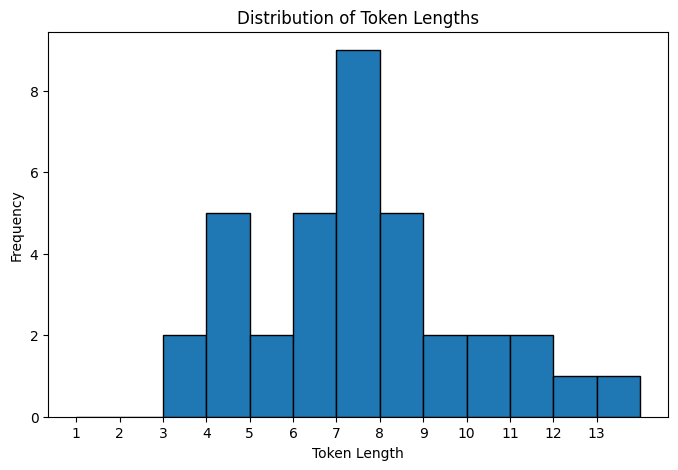

In [100]:
# Create a Polars DataFrame with tokens and their lengths
token_df = pl.DataFrame(
    {"token": clean_tokens, "length": [len(token) for token in clean_tokens]}
)

# Show the first few rows
print("Tokens with lengths:")
print(token_df.head())

# Compute average token length
avg_length = token_df["length"].mean()
print(f"\nAverage token length: {avg_length:.2f} characters")

# Plot a histogram of token lengths
plt.figure(figsize=(8, 5))
plt.hist(
    token_df["length"], bins=range(1, max(token_df["length"]) + 2), edgecolor='black'
)
plt.title("Distribution of Token Lengths")
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.xticks(range(1, max(token_df["length"]) + 1))
plt.show()

## Section 8. Build a Before/After Summary Table


This is a Markdown cell.

In [101]:
# Section 8 Python cell

summary_df: pl.DataFrame = pl.DataFrame(
    {
        "stage": [
            "raw tokens",
            "after punctuation removal",
            "after stop word removal",
        ],
        "count": [
            count_of_raw_tokens,
            count_of_tokens_no_punct,
            count_of_clean_tokens,
        ],
    }
)

print("Preprocessing summary:")
print(summary_df)

Preprocessing summary:
shape: (3, 2)
┌───────────────────────────┬───────┐
│ stage                     ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ i64   │
╞═══════════════════════════╪═══════╡
│ raw tokens                ┆ 45    │
│ after punctuation removal ┆ 45    │
│ after stop word removal   ┆ 36    │
└───────────────────────────┴───────┘


## Section 9. Build a Frequency Table with Polars

This is a Markdown cell.

In [102]:
# Section 9 Python cell

# Create a Polars DataFrame with one row per cleaned token.
token_df: pl.DataFrame = pl.DataFrame({"token": clean_tokens})

# Group by token, count occurrences, and sort from most common to least common.
freq_df: pl.DataFrame = token_df.group_by("token").len().sort("len", descending=True)

print("Top 20 most frequent cleaned tokens:")
print(freq_df.head(20))

Top 20 most frequent cleaned tokens:
shape: (20, 2)
┌───────────────┬─────┐
│ token         ┆ len │
│ ---           ┆ --- │
│ str           ┆ u64 │
╞═══════════════╪═════╡
│ sample        ┆ 2   │
│ results       ┆ 2   │
│ test          ┆ 2   │
│ documentation ┆ 1   │
│ analyze       ┆ 1   │
│ …             ┆ …   │
│ reports       ┆ 1   │
│ summarize     ┆ 1   │
│ traceability  ┆ 1   │
│ preparation   ┆ 1   │
│ helps         ┆ 1   │
└───────────────┴─────┘


## Section 10. Build a "Most Frequent Cleaned Tokens" Bar Chart


This is a Markdown cell.

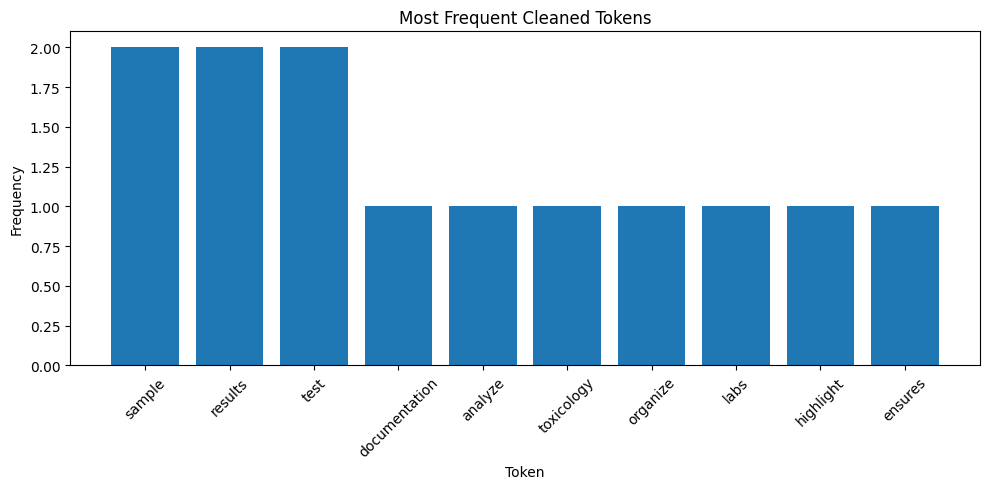

In [103]:
# Section 10 Python cell

top_df: pl.DataFrame = freq_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_df["token"], top_df["len"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Cleaned Tokens")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 11. Compare Raw vs Clean Token Counts


This is a Markdown cell.

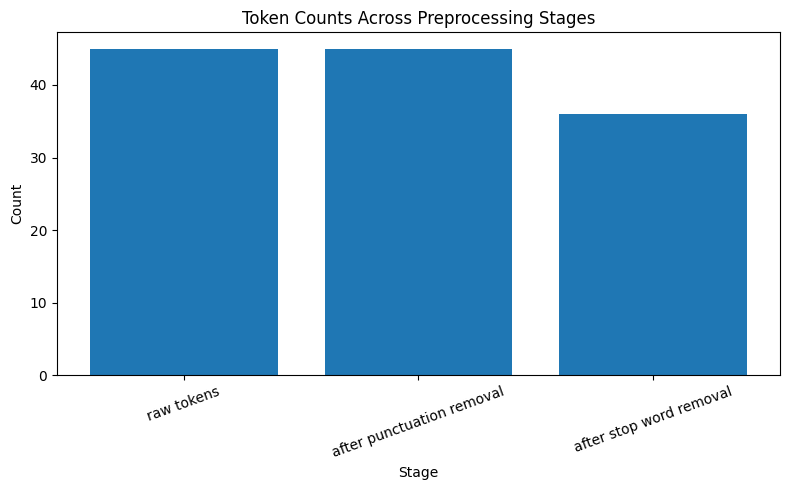

In [104]:
# Section 11 Python cell

plt.figure(figsize=(8, 5))
plt.bar(summary_df["stage"], summary_df["count"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=20)

plt.title("Token Counts Across Preprocessing Stages")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Section 12. Build a Word Cloud
This is a Markdown cell.

Sample of word frequencies:
sample: 2
results: 2
test: 2
documentation: 1
analyze: 1
toxicology: 1
organize: 1
labs: 1
highlight: 1
ensures: 1


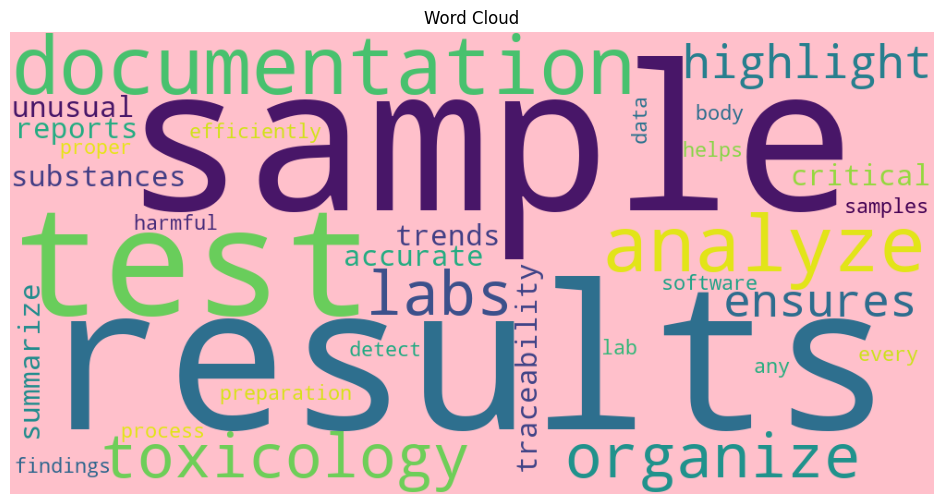

In [106]:
# For this, we want a Python dictionary
# mapping words to their frequencies.
# We can use the zip() function to combine the "word" and "len" columns into a dictionary.
# First, convert the frequency dfs to lists with to_list(),
# then zip() them together into a dictionary.
# strict=True ensures both lists are the same length.
freq_dict: dict[str, int] = dict(
    zip(freq_df["token"].to_list(), freq_df["len"].to_list(), strict=True)
)
print("Sample of word frequencies:")
for word, freq in list(freq_dict.items())[:10]:
    print(f"{word}: {freq}")

# Build a word cloud where larger words occur more frequently in the text.
# Set width and height in pixels and set the background color.
wc: WordCloud = WordCloud(width=1000, height=500, background_color="pink")

# Generate the word cloud from the frequency dictionary.
wc.generate_from_frequencies(freq_dict)

# Set the figure size in inches
plt.figure(figsize=(12, 6))

# Display the word cloud image with imshow() and turn off axes for a cleaner look.
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")

# Save the word cloud as an image (e.g., PNG)
plt.savefig("../docs/images/lab_wordcloud.png", dpi=300, bbox_inches="tight")

plt.show()

## Reminder: "Run All" before sending to GitHub

Before saving a notebook (and running git add-commit-push),
**click 'Run All'** to generate all outputs and display them in the notebook. 

After git add-commit-push, **verify your notebook appears** in your GitHub repo. 

This is a Markdown cell.
